# Native Language Identification - Author Profiling

### Fill with models you want to test:

Possible arguments for the Model:
- trait_name
    - 'language'
    - 'age'
    - 'gender'
    - 'political'
    - 'mbti'
- head_type
    - 'classification'
    - 'regression'
    - 'classreg' - an experimental regression head using 1 class classifier and it's raw logits
- train
    - 'Full'
    - 'LoRA'
    - 'Baseline' - this and above are fine-tunes on DistilBERT
    - 'MpNet'
    - 'RoBERT'
    - 'RoBERTLarge'

In [32]:
from Training.TESTING.shap.model_wrapper import Model

models = [
    Model('political', 'classreg', 'Full'),
    Model('political', 'regression', 'Full'),
    Model('political', 'regression', 'LoRA'),
    Model('political', 'regression', 'Baseline')
]


Initialized model political (Full)
Initialized model political (Full)
Initialized model political (LoRA)
Initialized model political (Baseline)


### Function for explanations

In [24]:
# models are loaded, explainers are loaded
import shap

def explain(text):
    for model in models:
        print(model.prediction_string(text))
        shap.plots.force(*model.explain(text), matplotlib=True, contribution_threshold=0.025)

### Test your text:

political (Full): left (0.04)


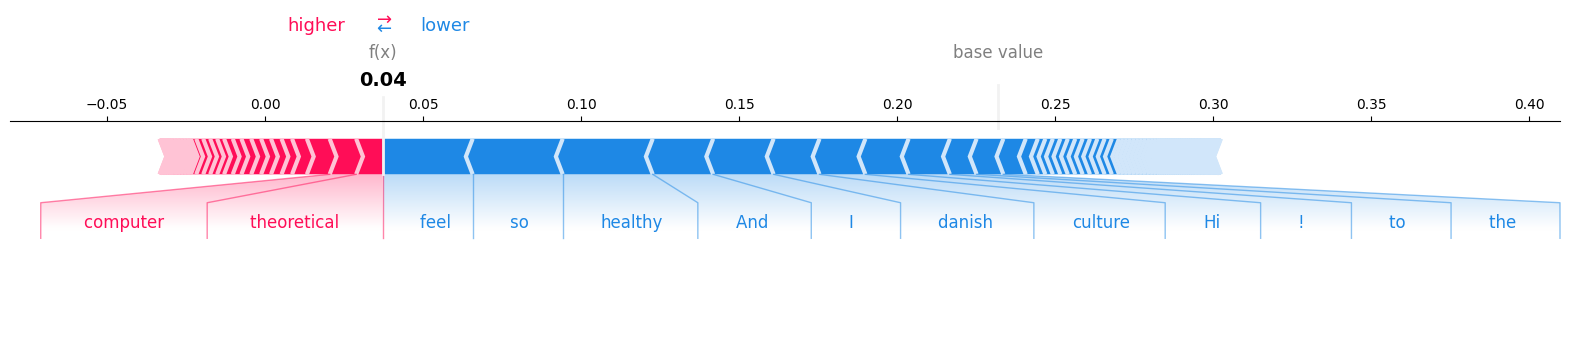

political (Full): left (-0.04)


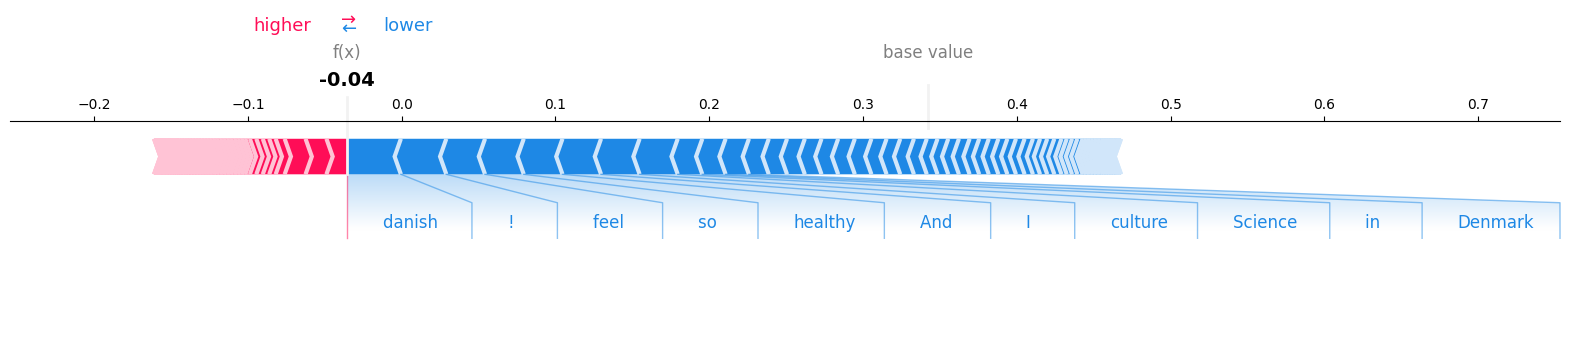

political (LoRA): center (0.55)


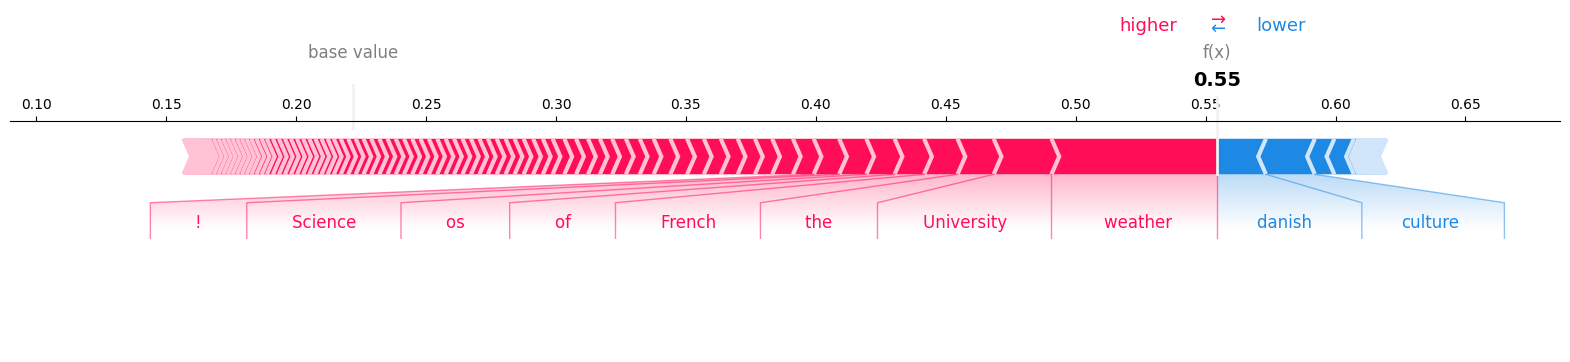

political (Baseline): center (0.65)


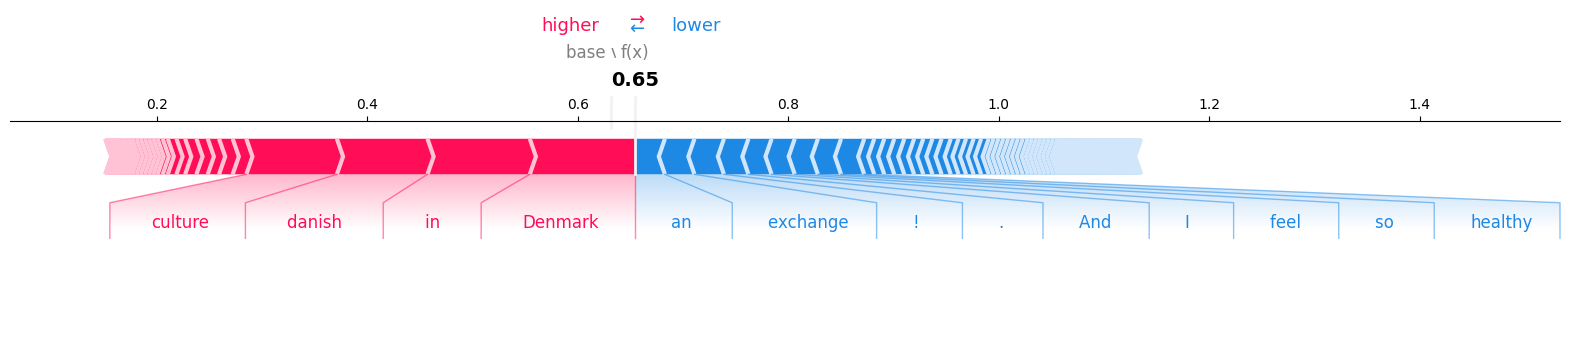

In [33]:
explain("Hi! I'm Nel os French University of Science and Technology - though right now I'm on an exchange in Denmark. I'm studying theoretical computer science and that was one university that had a similar field of study and matching courses. I'm actually starting to get accustomed to the danish culture. I was surprised to say this at first, but I actually like riding a bike every day to uni, even when the weather isn't nice. It has a certain appeal. And I feel so healthy.")

political (Full): center (0.55)


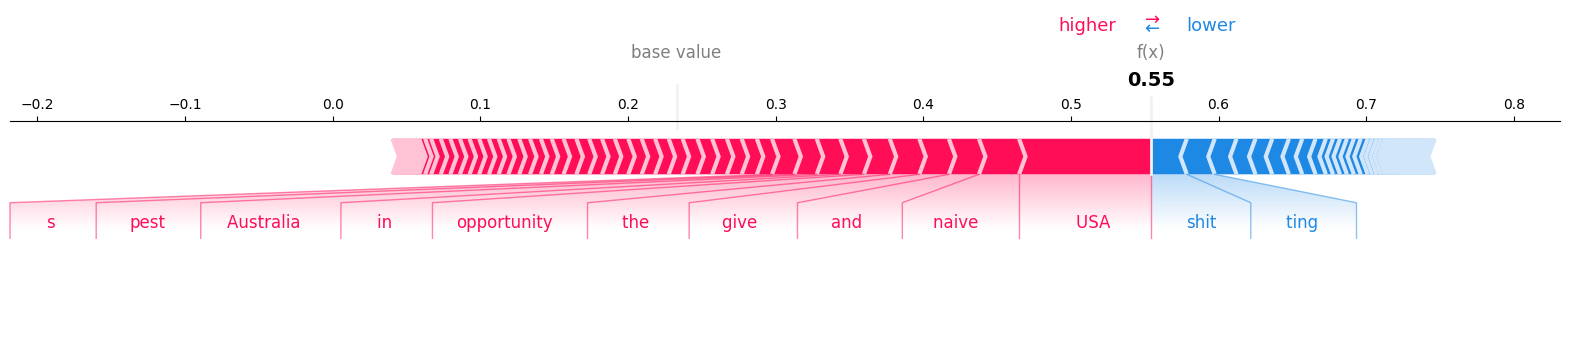

political (Full): center (1.04)


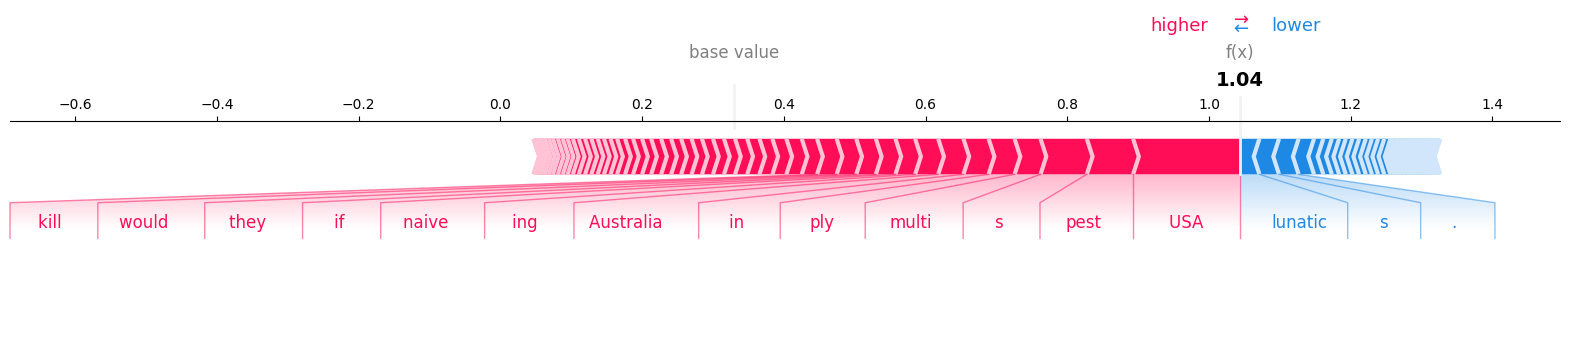

political (LoRA): center (0.57)


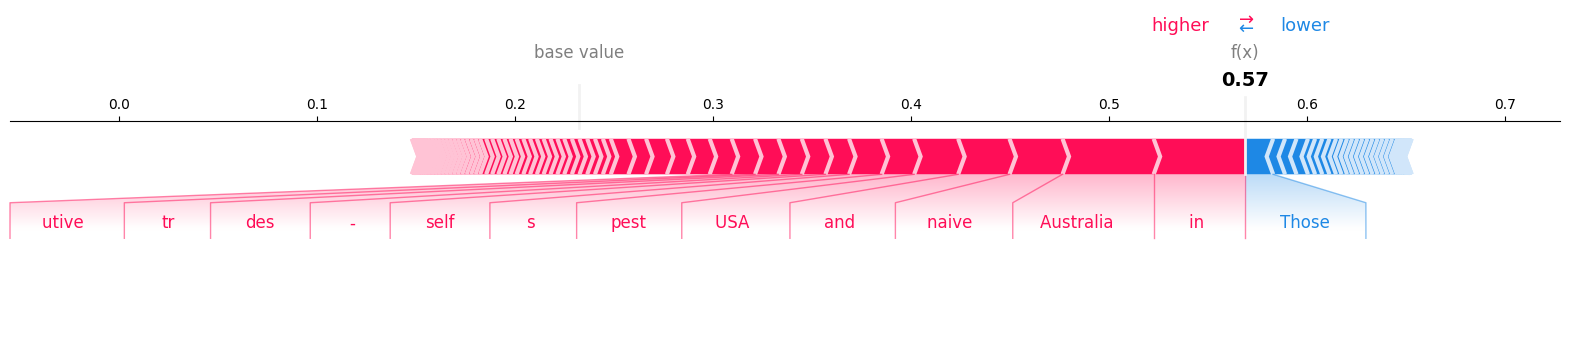

political (Baseline): center (0.58)


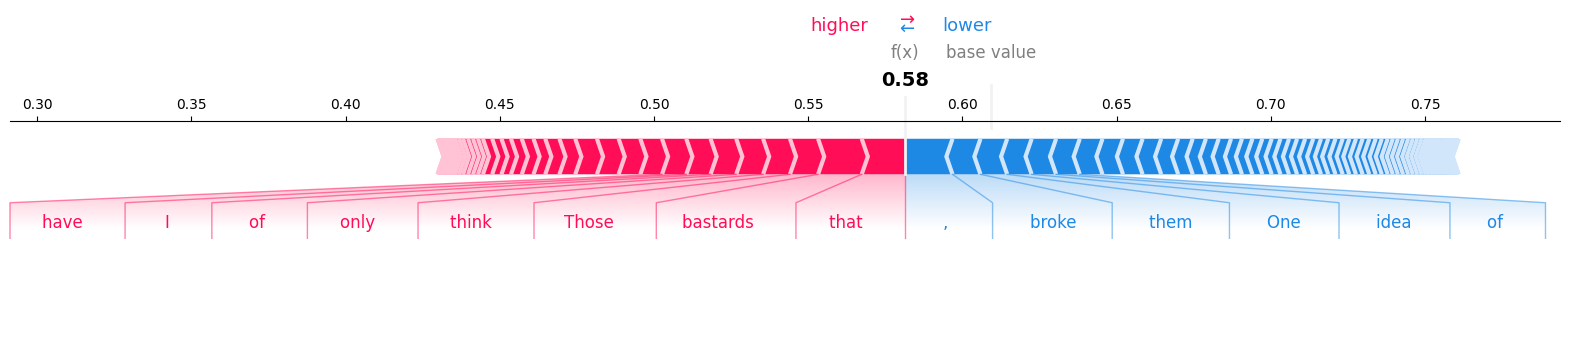

In [34]:
explain("I'm from USA and I fucking hate rabbits. Those ignorant, naive and self-destrutive bastards that think only of multiplying and shitting all over the place. I once took care of a pair for a family mamber and they kept jumping into the wall like some lunatics. One of them broke his leg doing this. I have no idea how they manage to be pests in Australia if they would kill themsleves give the opportunity. ")

political (Full): left (0.17)


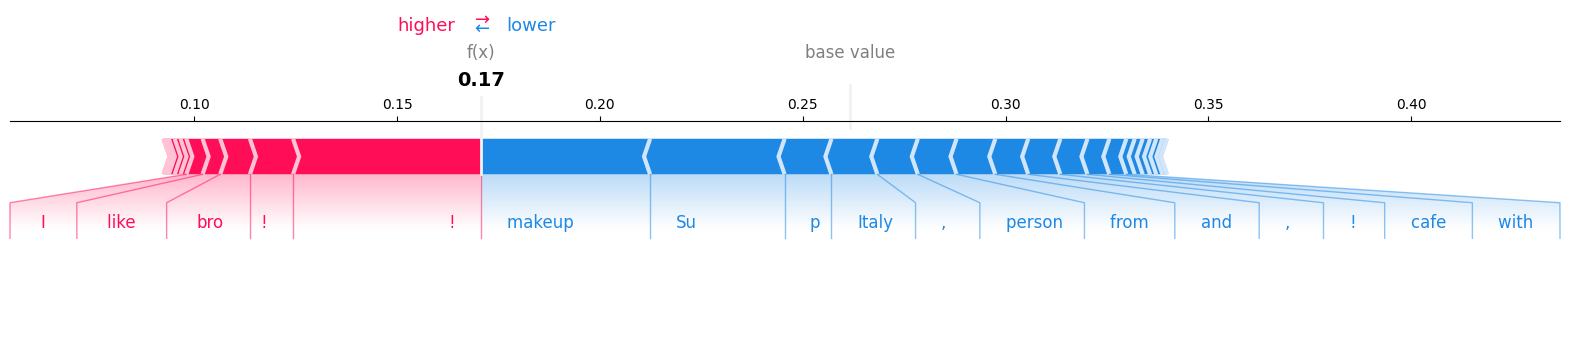

political (Full): left (0.18)


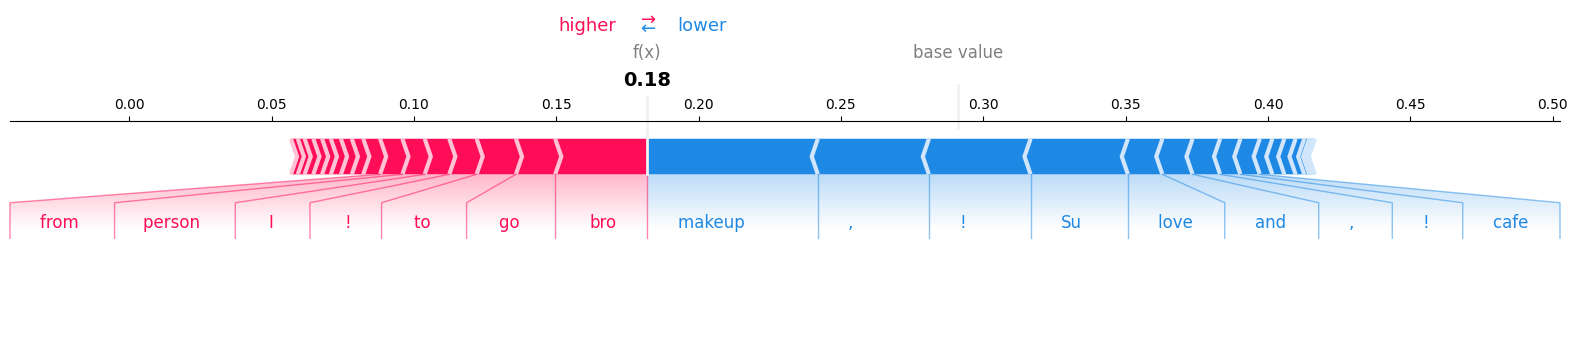

political (LoRA): left (0.50)


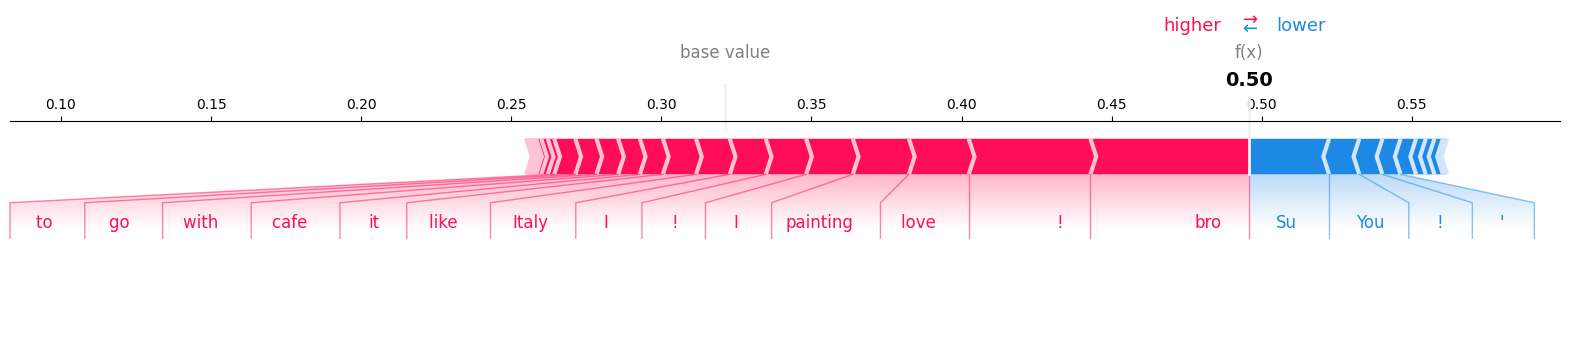

political (Baseline): center (0.61)


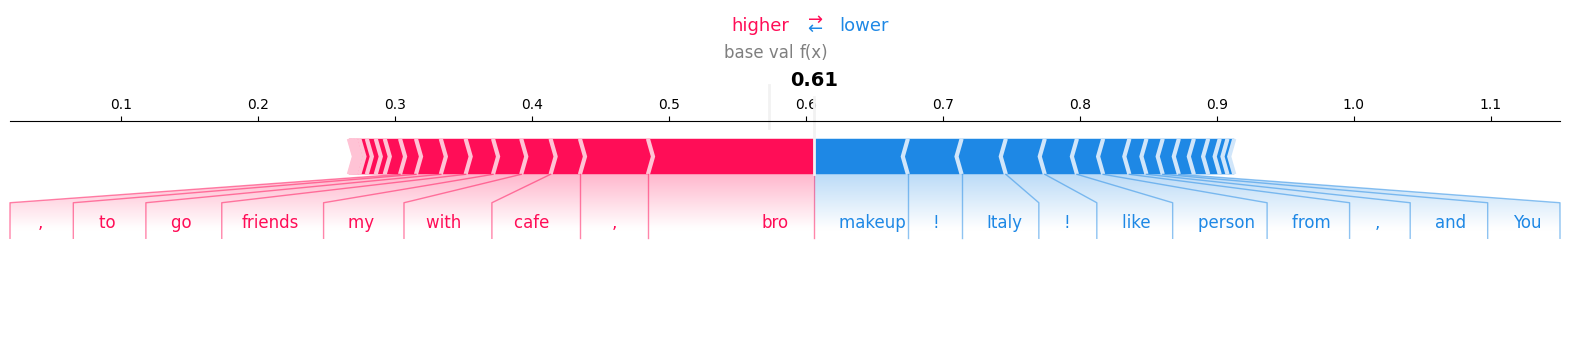

In [35]:
explain("Sup bro, You're a person from Italy, I like painting, makeup and go to cafe with my friends, I love it!!!")

political (Full): right (1.63)


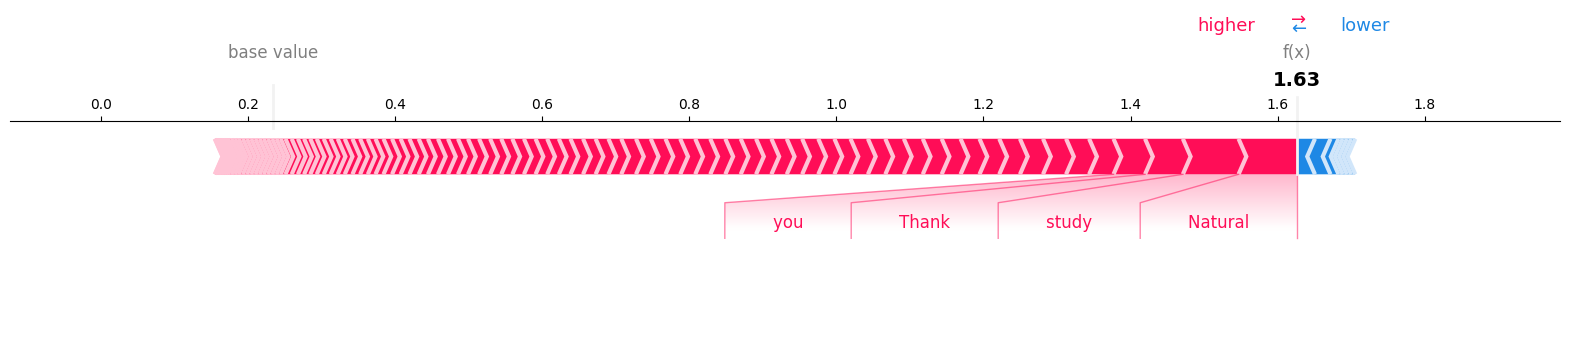

political (Full): right (1.92)


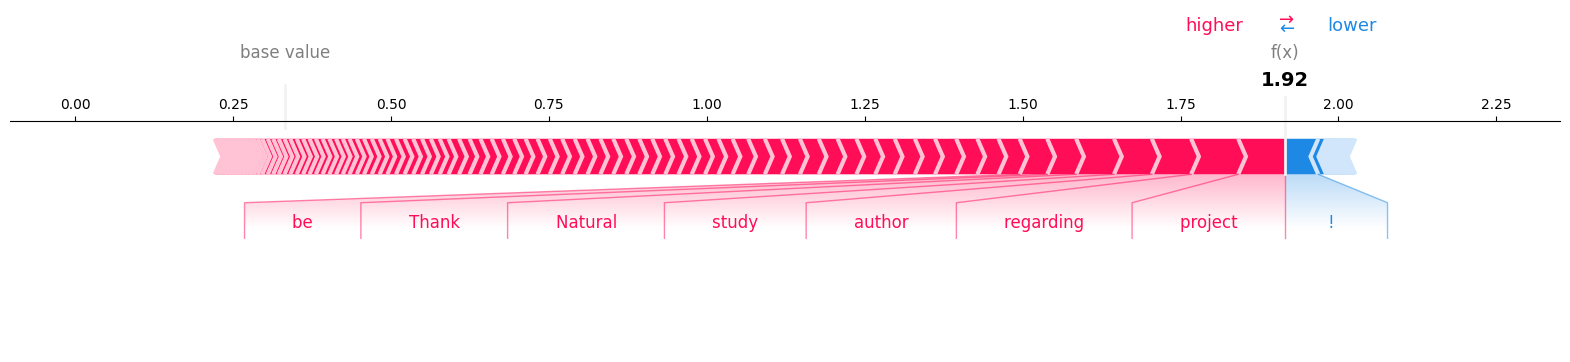

political (LoRA): center (1.15)


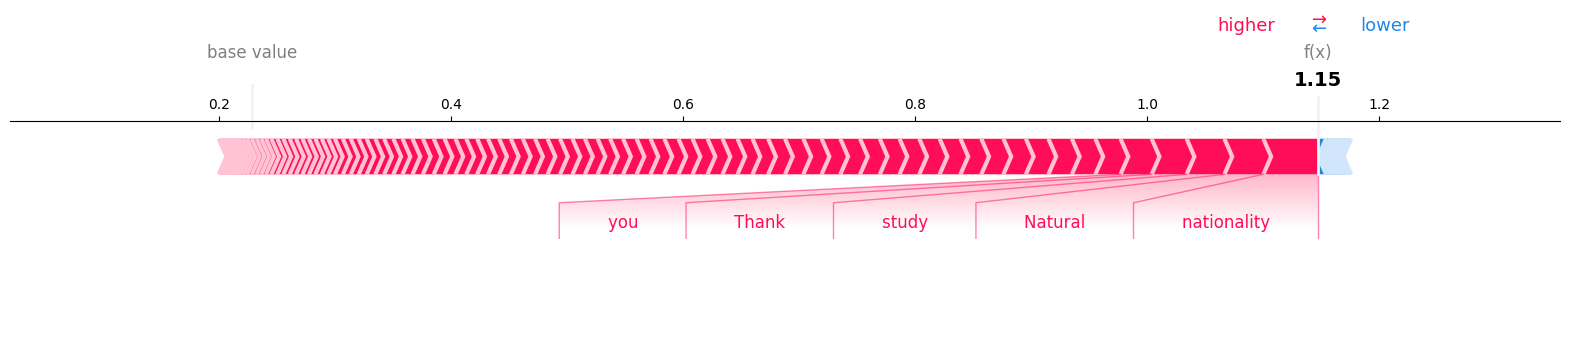

political (Baseline): center (0.86)


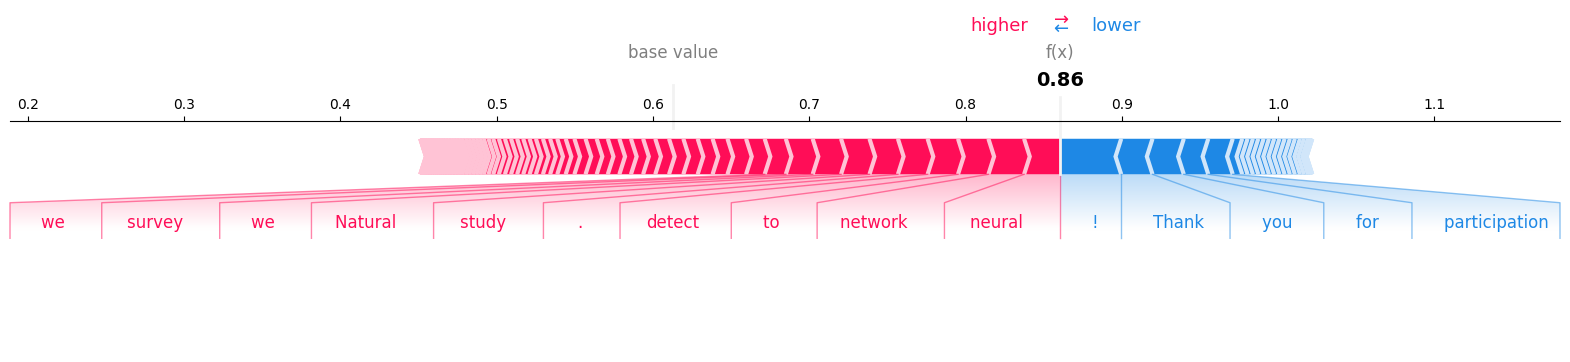

In [36]:
explain("Hi! We are making a project regarding author profiling in a field of study Natural Language Processing. With this survey we are going to collect data that we will use to train a neural network to detect, among other things, what language is your native based on the way you write in English. That is why we would be thankful if you answered questions about nationality honestly. Below you can se important information about how your data will be used. Thank you for participation in our project.")

political (Full): left (0.46)


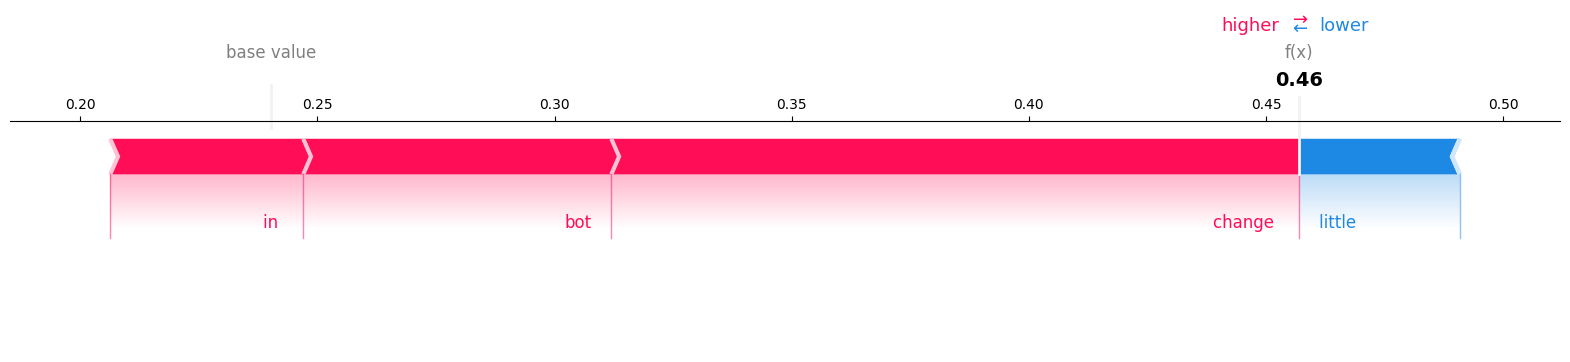

political (Full): left (0.25)


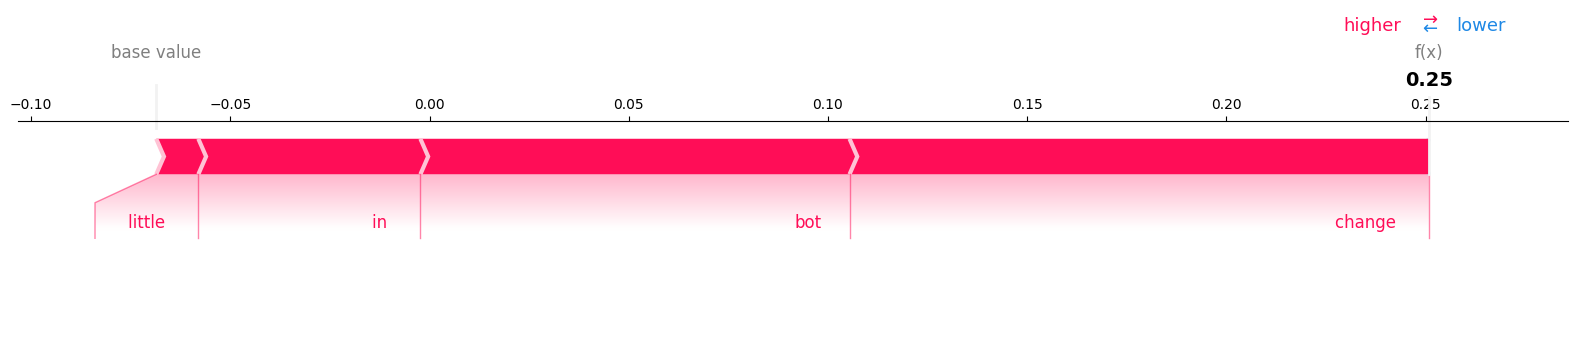

political (LoRA): center (0.72)


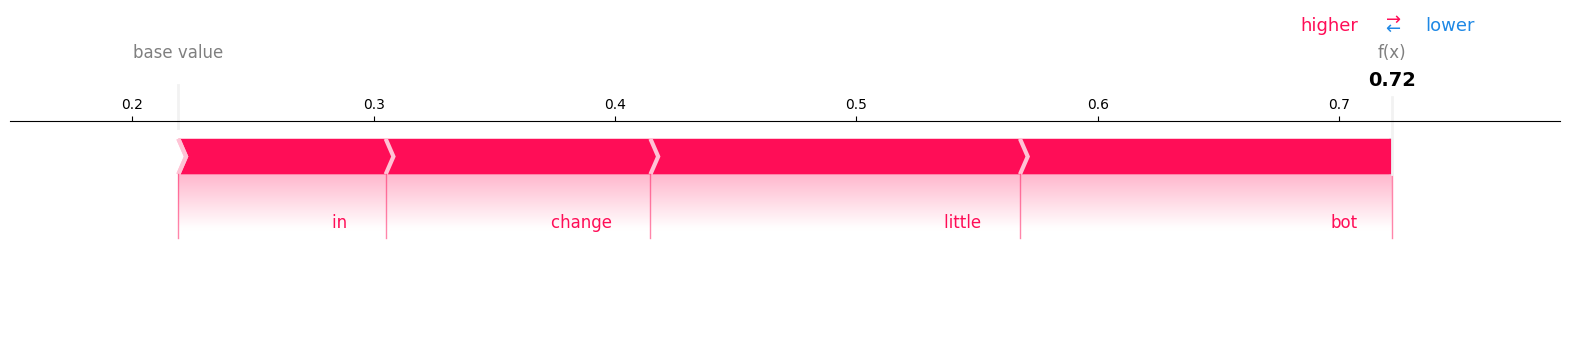

political (Baseline): center (1.05)


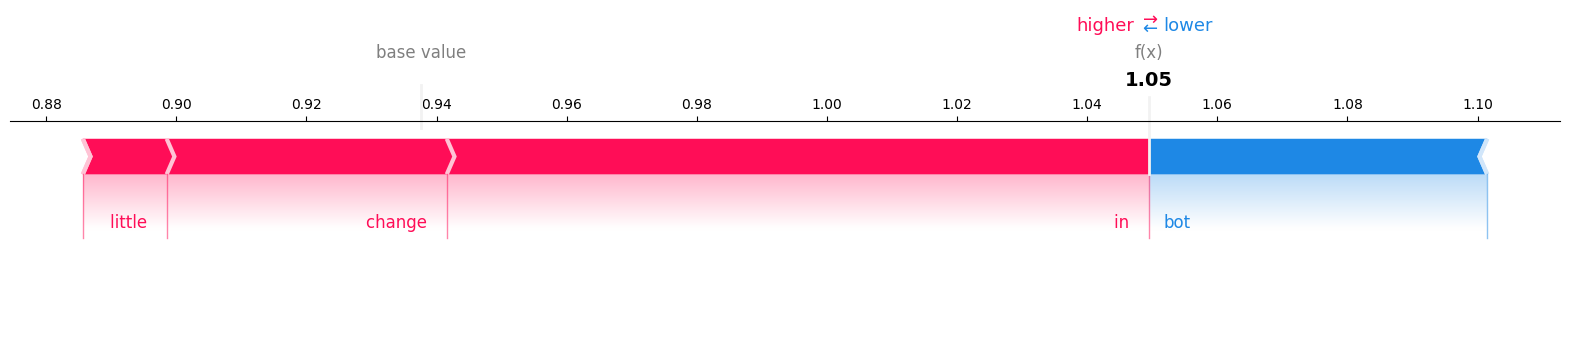

In [37]:
explain("little change in bot")

political (Full): right (1.62)


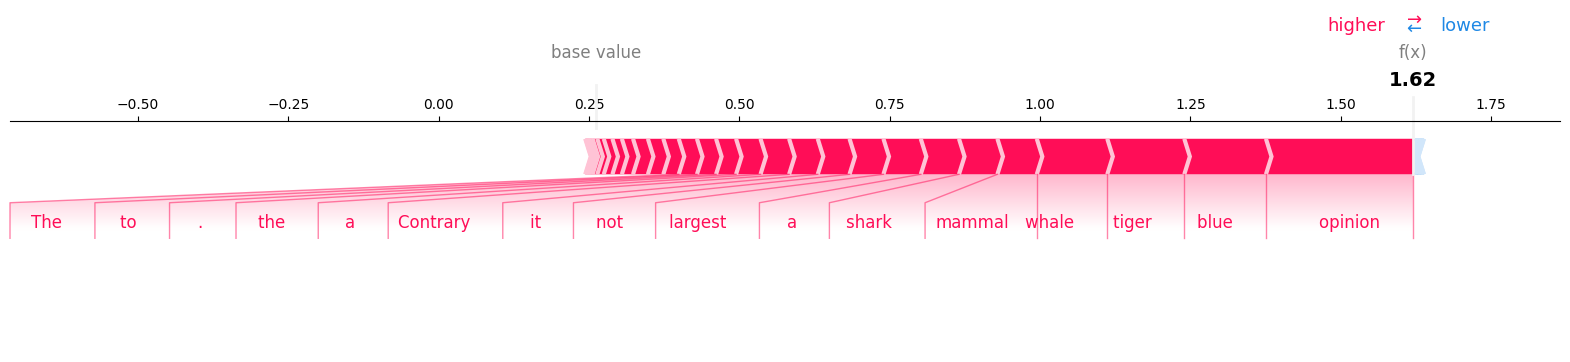

political (Full): right (1.77)


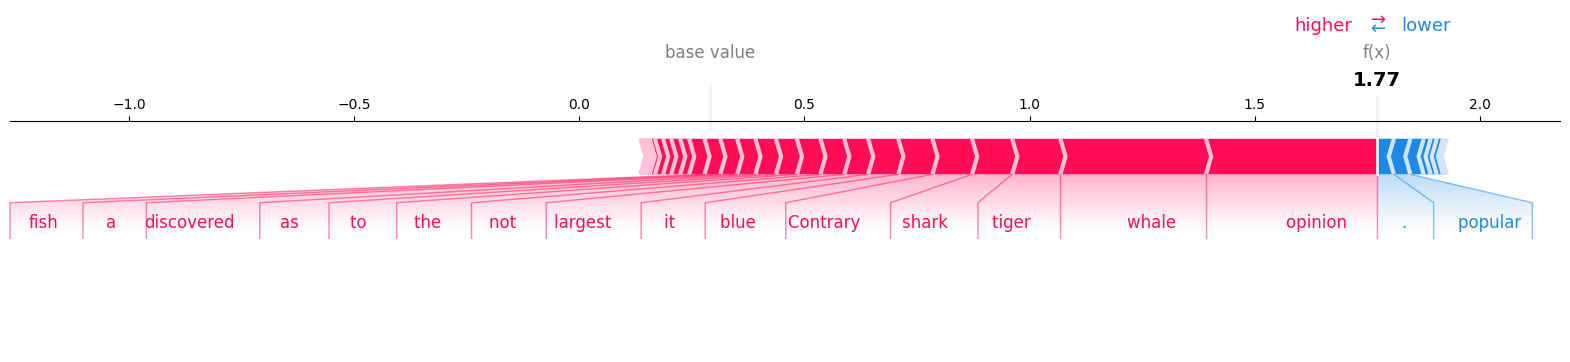

political (LoRA): right (1.77)


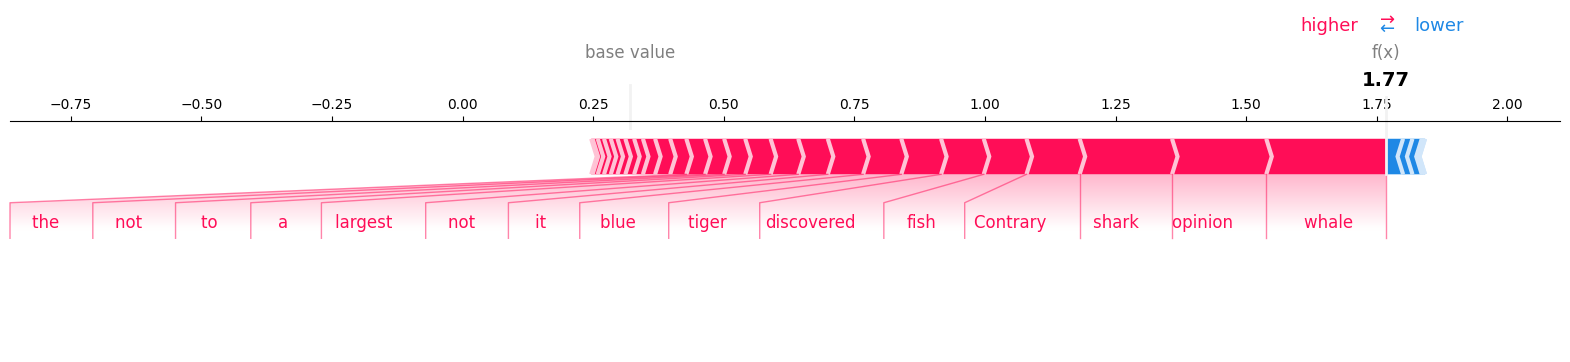

political (Baseline): center (1.45)


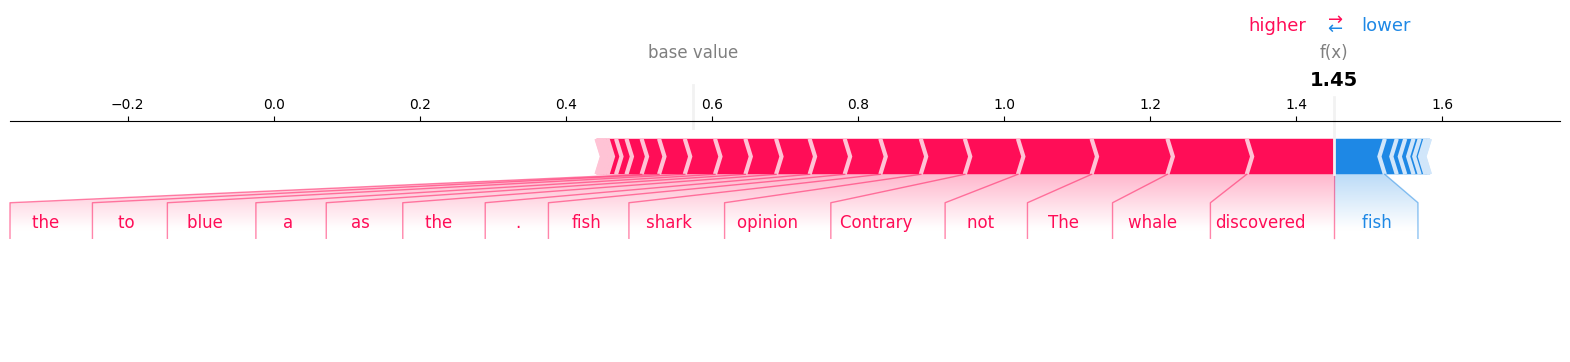

In [38]:
explain("The tiger shark is the largest fish ever discovered. Contrary to a popular opinion it is not the blue whale as it is a mammal, not a fish.")